# 05. Model Comparison

## Цель
Сравнить несколько линейных моделей и варианты набора признаков для задачи многоклассовой классификации бухгалтерских документов.

## Сравниваемые модели
В рамках данного этапа были протестированы следующие алгоритмы:
- `LogisticRegression`
- `LinearSVC`
- `RidgeClassifier`
- `SGDClassifier` с `loss="hinge"`
- `SGDClassifier` с `loss="log_loss"`
- `ComplementNB`

## Варианты признаков
Для большинства моделей были рассмотрены два варианта текстового представления:
1. без использования `Supplier_Name`;
2. с добавлением `Supplier_Name` в объединенный текстовый признак.

## Основные метрики
Для сравнения моделей использовались:
- `accuracy`
- `macro F1`
- `weighted F1`

Ключевой метрикой для выбора лучшей модели является `macro F1`, поскольку задача является многоклассовой, а классы распределены неравномерно.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.linear_model import RidgeClassifier, SGDClassifier
from sklearn.naive_bayes import ComplementNB
import joblib
from scipy import sparse
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 200)

In [2]:
merged_df = pd.read_csv("../data/modified/merged_dataframe.csv")
merged_df.head()

,Dataset,Date,Invoice,Supplier_Code,Supplier_Name,Invoice_Item,Item_Description,Item_Value,Item_Quantity,Total_Amount,Taxes_Credit_%,Taxes_Credit_Amount,Total_Net_Amount,Account_Number,Account_Description,Activity_Code,Activity_Description
0,Training,2019-08-15,91,10001,ABS & ABC Tax Consulting,1,Review of federal tax obligations,2000,1,2000,0,0.0,2000.0,4000010,Audit and Consulting,7020400,"Business management consulting, except specialized technical consulting"
1,Training,2019-08-15,186,10002,HJU Travel Agency,1,Assistance with flight and hotel arrangements,500,1,500,0,0.0,500.0,4000080,Other Third-Party Services,7911200,Travel agencies
2,Training,2019-08-15,275,10003,ABC Associated Lawyers,1,Legal advisory in labor lawsuit,2000,1,2000,0,0.0,2000.0,4000012,Legal Services,6911701,Legal services
3,Training,2019-08-15,135,10004,ATY Business Consulting,1,Consulting on zero-based budgeting,15000,1,15000,0,0.0,15000.0,4000010,Audit and Consulting,7020400,"Business management consulting, except specialized technical consulting"
4,Training,2019-08-15,221,10005,HBG Security and Surveillance,1,Provision of 2 security guards for gate,15000,1,15000,0,0.0,15000.0,4000015,Security and Surveillance,8020001,Electronic security system monitoring activities


In [3]:
merged_df["Date"] = pd.to_datetime(merged_df["Date"], errors="coerce")
merged_df["Year"] = merged_df["Date"].dt.year
merged_df["Month"] = merged_df["Date"].dt.month
merged_df["Day"] = merged_df["Date"].dt.day
merged_df["Item_Description_Length"] = merged_df["Item_Description"].astype(str).str.len()
merged_df["Item_Description_Word_Count"] = merged_df["Item_Description"].astype(str).str.split().str.len()
merged_df["Has_Tax_Credit"] = (merged_df["Taxes_Credit_Amount"] > 0).astype(int)
text_cols_to_clean = ["Item_Description", "Activity_Description", "Supplier_Name"]
for col in text_cols_to_clean:
    merged_df[col] = (
        merged_df[col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

In [4]:
train_df = merged_df[merged_df["Dataset"] == "Training"].copy()
test_df = merged_df[merged_df["Dataset"] == "Test"].copy()

In [5]:
target_col = "Account_Number"
y_train = train_df[target_col].copy()
y_test = test_df[target_col].copy()

In [6]:
def squeeze_text_column(x):
    return x.squeeze()

In [7]:
def prepare_features(train_df, test_df, use_supplier_name=False):
    numeric_features = [
        "Item_Value",
        "Item_Quantity",
        "Taxes_Credit_%",
        "Taxes_Credit_Amount",
        "Month",
        "Item_Description_Length",
        "Item_Description_Word_Count",
        "Has_Tax_Credit"
    ]
    train_work = train_df.copy()
    test_work = test_df.copy()
    if use_supplier_name:
        train_work["Combined_Text"] = (
            train_work["Item_Description"].fillna("") + " " +
            train_work["Activity_Description"].fillna("") + " " +
            train_work["Supplier_Name"].fillna("")
        )
        test_work["Combined_Text"] = (
            test_work["Item_Description"].fillna("") + " " +
            test_work["Activity_Description"].fillna("") + " " +
            test_work["Supplier_Name"].fillna("")
        )
    else:
        train_work["Combined_Text"] = (
            train_work["Item_Description"].fillna("") + " " +
            train_work["Activity_Description"].fillna("")
        )
        test_work["Combined_Text"] = (
            test_work["Item_Description"].fillna("") + " " +
            test_work["Activity_Description"].fillna("")
        )
    final_text_feature = "Combined_Text"
    X_train_final = train_work[[final_text_feature] + numeric_features].copy()
    X_test_final = test_work[[final_text_feature] + numeric_features].copy()
    text_preprocessor = Pipeline(steps=[
        ("extract_text", FunctionTransformer(squeeze_text_column, validate=False)),
        ("tfidf", TfidfVectorizer(
            lowercase=False,
            ngram_range=(1, 2),
            min_df=2
        ))
    ])
    numeric_preprocessor = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    preprocessor = ColumnTransformer(
        transformers=[
            ("text", text_preprocessor, [final_text_feature]),
            ("num", numeric_preprocessor, numeric_features)
        ]
    )
    X_train_processed = preprocessor.fit_transform(X_train_final)
    X_test_processed = preprocessor.transform(X_test_final)
    return X_train_processed, X_test_processed, preprocessor

In [8]:
def evaluate_model(model, model_name, feature_variant, X_train_processed, X_test_processed, y_train, y_test):
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)
    
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")
    
    result = {
        "model": model_name,
        "feature_variant": feature_variant,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "y_pred": y_pred
    }
    return result

In [9]:
def prepare_text_only_features(train_df, test_df, use_supplier_name=False):
    train_work = train_df.copy()
    test_work = test_df.copy()

    if use_supplier_name:
        train_work["Combined_Text"] = (
            train_work["Item_Description"].fillna("") + " " +
            train_work["Activity_Description"].fillna("") + " " +
            train_work["Supplier_Name"].fillna("")
        )
        test_work["Combined_Text"] = (
            test_work["Item_Description"].fillna("") + " " +
            test_work["Activity_Description"].fillna("") + " " +
            test_work["Supplier_Name"].fillna("")
        )
    else:
        train_work["Combined_Text"] = (
            train_work["Item_Description"].fillna("") + " " +
            train_work["Activity_Description"].fillna("")
        )
        test_work["Combined_Text"] = (
            test_work["Item_Description"].fillna("") + " " +
            test_work["Activity_Description"].fillna("")
        )
    vectorizer = TfidfVectorizer(
        lowercase=False,
        ngram_range=(1, 2),
        min_df=2
    )
    X_train = vectorizer.fit_transform(train_work["Combined_Text"])
    X_test = vectorizer.transform(test_work["Combined_Text"])
    return X_train, X_test, vectorizer

In [10]:
X_train_no_supplier, X_test_no_supplier, preprocessor_no_supplier = prepare_features(
    train_df=train_df,
    test_df=test_df,
    use_supplier_name=False
)
shape_no_supplier = pd.DataFrame({
    "matrix": ["X_train_no_supplier", "X_test_no_supplier"],
    "rows": [X_train_no_supplier.shape[0], X_test_no_supplier.shape[0]],
    "cols": [X_train_no_supplier.shape[1], X_test_no_supplier.shape[1]]
})
display(shape_no_supplier)

,matrix,rows,cols
0,X_train_no_supplier,292,318
1,X_test_no_supplier,51,318


In [11]:
X_train_with_supplier, X_test_with_supplier, preprocessor_with_supplier = prepare_features(
    train_df=train_df,
    test_df=test_df,
    use_supplier_name=True
)
shape_with_supplier = pd.DataFrame({
    "matrix": ["X_train_with_supplier", "X_test_with_supplier"],
    "rows": [X_train_with_supplier.shape[0], X_test_with_supplier.shape[0]],
    "cols": [X_train_with_supplier.shape[1], X_test_with_supplier.shape[1]]
})
display(shape_with_supplier)

,matrix,rows,cols
0,X_train_with_supplier,292,448
1,X_test_with_supplier,51,448


In [12]:
model_specs = [
    {
        "model_name": "LogisticRegression",
        "model": LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ),
        "supports_mixed_features": True
    },
    {
        "model_name": "LinearSVC",
        "model": LinearSVC(
            class_weight="balanced",
            random_state=42
        ),
        "supports_mixed_features": True
    },
    {
        "model_name": "RidgeClassifier",
        "model": RidgeClassifier(
            class_weight="balanced"
        ),
        "supports_mixed_features": True
    },
    {
        "model_name": "SGDClassifier_hinge",
        "model": SGDClassifier(
            loss="hinge",
            class_weight="balanced",
            random_state=42,
            max_iter=2000
        ),
        "supports_mixed_features": True
    },
    {
        "model_name": "SGDClassifier_log_loss",
        "model": SGDClassifier(
            loss="log_loss",
            class_weight="balanced",
            random_state=42,
            max_iter=2000
        ),
        "supports_mixed_features": True
    },
    {
        "model_name": "ComplementNB",
        "model": ComplementNB(),
        "supports_mixed_features": False
    }
]

In [13]:
feature_variants = [
    {
        "feature_variant": "without_supplier_name",
        "use_supplier_name": False
    },
    {
        "feature_variant": "with_supplier_name",
        "use_supplier_name": True
    }
]

In [14]:
results = []
for feature_cfg in feature_variants:
    feature_variant_name = feature_cfg["feature_variant"]
    use_supplier_name = feature_cfg["use_supplier_name"]
    X_train_mixed, X_test_mixed, _ = prepare_features(
        train_df=train_df,
        test_df=test_df,
        use_supplier_name=use_supplier_name
    )
    X_train_text, X_test_text, _ = prepare_text_only_features(
        train_df=train_df,
        test_df=test_df,
        use_supplier_name=use_supplier_name
    )
    for spec in model_specs:
        if spec["supports_mixed_features"]:
            X_train_current = X_train_mixed
            X_test_current = X_test_mixed
        else:
            X_train_current = X_train_text
            X_test_current = X_test_text
        result = evaluate_model(
            model=spec["model"],
            model_name=spec["model_name"],
            feature_variant=feature_variant_name,
            X_train_processed=X_train_current,
            X_test_processed=X_test_current,
            y_train=y_train,
            y_test=y_test
        )
        results.append(result)

In [15]:
comparison_df = pd.DataFrame([
    {
        "model": r["model"],
        "feature_variant": r["feature_variant"],
        "accuracy": r["accuracy"],
        "macro_f1": r["macro_f1"],
        "weighted_f1": r["weighted_f1"]
    }
    for r in results
])
comparison_df = comparison_df.sort_values(
    ["macro_f1", "weighted_f1", "accuracy"],
    ascending=False
).reset_index(drop=True)
display(comparison_df)

,model,feature_variant,accuracy,macro_f1,weighted_f1
0,SGDClassifier_hinge,with_supplier_name,0.901961,0.824359,0.905229
1,RidgeClassifier,with_supplier_name,0.901961,0.810606,0.910873
2,LinearSVC,with_supplier_name,0.921569,0.795062,0.920261
3,SGDClassifier_log_loss,with_supplier_name,0.921569,0.795062,0.920261
4,ComplementNB,with_supplier_name,0.882353,0.774951,0.850190
5,RidgeClassifier,without_supplier_name,0.882353,0.761461,0.882551
6,SGDClassifier_hinge,without_supplier_name,0.803922,0.733826,0.771864
7,LinearSVC,without_supplier_name,0.882353,0.720988,0.874510
8,ComplementNB,without_supplier_name,0.862745,0.710684,0.822976
9,SGDClassifier_log_loss,without_supplier_name,0.843137,0.687991,0.832442


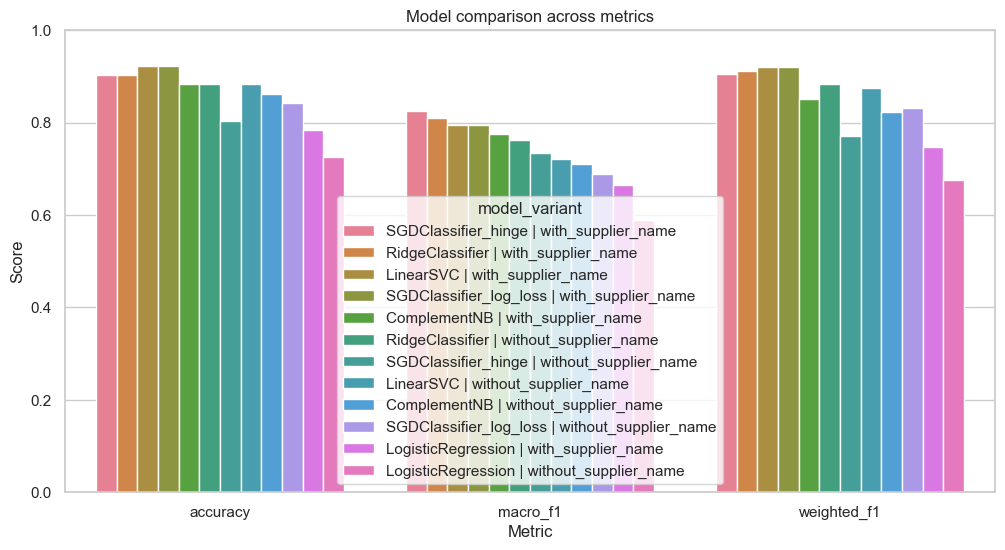

,model,feature_variant,accuracy,macro_f1,weighted_f1
0,SGDClassifier_hinge,with_supplier_name,0.901961,0.824359,0.905229
1,RidgeClassifier,with_supplier_name,0.901961,0.810606,0.910873
2,LinearSVC,with_supplier_name,0.921569,0.795062,0.920261
3,SGDClassifier_log_loss,with_supplier_name,0.921569,0.795062,0.920261
4,ComplementNB,with_supplier_name,0.882353,0.774951,0.850190
5,RidgeClassifier,without_supplier_name,0.882353,0.761461,0.882551
6,SGDClassifier_hinge,without_supplier_name,0.803922,0.733826,0.771864
7,LinearSVC,without_supplier_name,0.882353,0.720988,0.874510
8,ComplementNB,without_supplier_name,0.862745,0.710684,0.822976
9,SGDClassifier_log_loss,without_supplier_name,0.843137,0.687991,0.832442


In [16]:
comparison_long = comparison_df.melt(
    id_vars=["model", "feature_variant"],
    value_vars=["accuracy", "macro_f1", "weighted_f1"],
    var_name="metric",
    value_name="value"
)
comparison_long["model_variant"] = comparison_long["model"] + " | " + comparison_long["feature_variant"]
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_long, x="metric", y="value", hue="model_variant")
plt.title("Model comparison across metrics")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()
display(comparison_df)

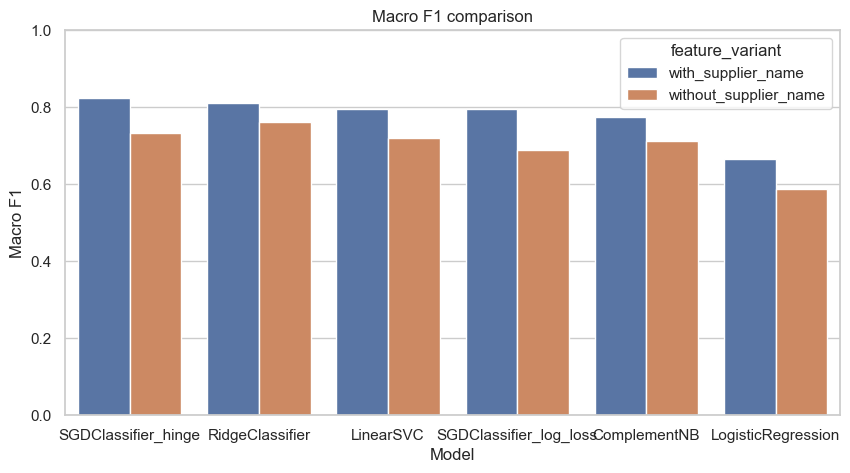

,model,feature_variant,macro_f1
0,SGDClassifier_hinge,with_supplier_name,0.824359
1,RidgeClassifier,with_supplier_name,0.810606
2,LinearSVC,with_supplier_name,0.795062
3,SGDClassifier_log_loss,with_supplier_name,0.795062
4,ComplementNB,with_supplier_name,0.774951
5,RidgeClassifier,without_supplier_name,0.761461
6,SGDClassifier_hinge,without_supplier_name,0.733826
7,LinearSVC,without_supplier_name,0.720988
8,ComplementNB,without_supplier_name,0.710684
9,SGDClassifier_log_loss,without_supplier_name,0.687991


In [17]:
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x="model", y="macro_f1", hue="feature_variant")
plt.title("Macro F1 comparison")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.show()
display(comparison_df[["model", "feature_variant", "macro_f1"]].sort_values("macro_f1", ascending=False))

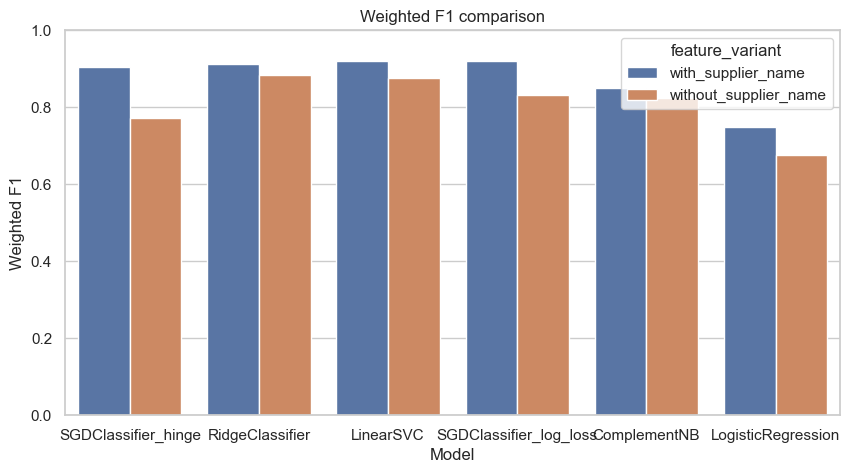

,model,feature_variant,weighted_f1
3,SGDClassifier_log_loss,with_supplier_name,0.920261
2,LinearSVC,with_supplier_name,0.920261
1,RidgeClassifier,with_supplier_name,0.910873
0,SGDClassifier_hinge,with_supplier_name,0.905229
5,RidgeClassifier,without_supplier_name,0.882551
7,LinearSVC,without_supplier_name,0.874510
4,ComplementNB,with_supplier_name,0.850190
9,SGDClassifier_log_loss,without_supplier_name,0.832442
8,ComplementNB,without_supplier_name,0.822976
6,SGDClassifier_hinge,without_supplier_name,0.771864


In [18]:
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x="model", y="weighted_f1", hue="feature_variant")
plt.title("Weighted F1 comparison")
plt.xlabel("Model")
plt.ylabel("Weighted F1")
plt.ylim(0, 1)
plt.show()
display(comparison_df[["model", "feature_variant", "weighted_f1"]].sort_values("weighted_f1", ascending=False))

In [19]:
best_model_row = comparison_df.iloc[0:1]
display(best_model_row)

,model,feature_variant,accuracy,macro_f1,weighted_f1
0,SGDClassifier_hinge,with_supplier_name,0.901961,0.824359,0.905229


In [20]:
best_result = None
for r in results:
    if (
        r["model"] == best_model_row.iloc[0]["model"] and
        r["feature_variant"] == best_model_row.iloc[0]["feature_variant"]
    ):
        best_result = r
        break

In [21]:
best_report = classification_report(
    y_test,
    best_result["y_pred"],
    output_dict=True,
    zero_division=0
)
best_report_df = pd.DataFrame(best_report).T
display(best_report_df)

,precision,recall,f1-score,support
1000001,1.000000,1.000000,1.000000,6.000000
1001002,0.000000,0.000000,0.000000,0.000000
1001004,0.000000,0.000000,0.000000,2.000000
4000006,1.000000,0.500000,0.666667,2.000000
4000010,1.000000,1.000000,1.000000,6.000000
4000012,1.000000,1.000000,1.000000,3.000000
4000013,0.000000,0.000000,0.000000,0.000000
4000015,1.000000,1.000000,1.000000,2.000000
4000017,1.000000,1.000000,1.000000,1.000000
4000021,0.333333,1.000000,0.500000,1.000000


In [22]:
X_train_best, X_test_best, preprocessor_best = prepare_features(
    train_df=train_df,
    test_df=test_df,
    use_supplier_name=True
)

In [23]:
train_best_readable = train_df.copy()
test_best_readable = test_df.copy()
train_best_readable["Combined_Text"] = (
    train_best_readable["Item_Description"].fillna("") + " " +
    train_best_readable["Activity_Description"].fillna("") + " " +
    train_best_readable["Supplier_Name"].fillna("")
)
test_best_readable["Combined_Text"] = (
    test_best_readable["Item_Description"].fillna("") + " " +
    test_best_readable["Activity_Description"].fillna("") + " " +
    test_best_readable["Supplier_Name"].fillna("")
)

In [24]:
sparse.save_npz("../data/modified/X_train_best_model.npz", X_train_best)
sparse.save_npz("../data/modified/X_test_best_model.npz", X_test_best)
y_train.to_csv("../data/modified/y_train_best_model.csv", index=False)
y_test.to_csv("../data/modified/y_test_best_model.csv", index=False)
train_best_readable.to_csv("../data/modified/train_best_model_readable.csv", index=False)
test_best_readable.to_csv("../data/modified/test_best_model_readable.csv", index=False)
joblib.dump(preprocessor_best, "../artifacts/preprocessor_best_model.joblib")

['../artifacts/preprocessor_best_model.joblib']

## Итоги сравнения моделей

В ходе данного этапа было выполнено сравнение нескольких алгоритмов классификации на подготовленных текстовых и числовых признаках.

### Основные результаты
1. Исходная baseline-модель `LogisticRegression` показала наименьшее качество среди протестированных подходов.
2. Линейные модели, ориентированные на работу с разреженными текстовыми признаками, продемонстрировали существенно лучшие результаты.
3. Добавление `Supplier_Name` улучшило качество большинства моделей, что подтверждает высокую информативность этого признака.
4. Наилучший результат по основной метрике `macro F1` показала модель `SGDClassifier` с функцией потерь `hinge` и использованием `Supplier_Name`.

### Лучшая модель
Лучшая конфигурация по метрике `macro F1`:
- **модель:** `SGDClassifier_hinge`
- **вариант признаков:** `with_supplier_name`
- **accuracy:** 0.902
- **macro F1:** 0.824
- **weighted F1:** 0.905

### Дополнительное наблюдение
Наивысшую `accuracy` показали `LinearSVC` и `SGDClassifier_log_loss` с `Supplier_Name`, однако по `macro F1` они уступили `SGDClassifier_hinge`. Поскольку в данной задаче важно качество классификации по всем классам, включая редкие, в качестве основной модели для дальнейшей работы выбирается именно `SGDClassifier_hinge` с `Supplier_Name`.

### Следующие шаги
На следующих этапах будет использоваться выбранная лучшая модель для:
1. более детального анализа ошибок;
2. интерпретации предсказаний;
3. подготовки итогового решения и финальных выводов по проекту.